# Notebook 1: Baseline Analytical Optimization

This notebook walks through the **minimum viable workflow** of the
`current_setpoints` library: given a multiphase machine, find the DQ
current setpoints that maximise efficiency at every (torque, speed)
operating point under current and voltage limits.

The optimization here uses the **analytical** torque model — a closed-form
quadratic in the DQ currents. Notebook 2 swaps in a neural torque model;
notebook 3 compares the two.

**What this notebook produces**

- `data/IEEETIE_machine2_baseline.pkl` — a dictionary of optimal DQ currents
  and operating-regime labels on a `(torque, omega)` grid.
- A segments plot showing which regime (MTPA, flux-weakening, etc.) is
  active in each cell of the grid.

**Prerequisites**: none. This is the entry point.

## 0. Imports and paths

Standard setup. The library is imported as `current_setpoints`; we also
make sure the parent directory is on `sys.path` so the notebook works
when launched from anywhere.

In [ ]:
import os
import pickle
import sys

import numpy as np

root_dir = os.path.abspath("..")
data_dir = os.path.join(root_dir, "data")
os.makedirs(data_dir, exist_ok=True)
if root_dir not in sys.path:
    sys.path.append(root_dir)

from current_setpoints.parameters import Flux_IEEEMachine2, IEEEMachine2
from current_setpoints.simulation import Transform
from current_setpoints.optimization import (
    ModelAnalytical,
    MotorOptimizer,
    calculate_grid,
    grid_to_data,
)
from current_setpoints.utils.plotting import plot_grid_segments

## 1. The machine model

The `BaseMachine` class holds the physical parameters of a multiphase
machine: number of phases, pole pairs, stator resistance, stator
inductance, and the cross-coupling matrix that encodes harmonic
interactions in the DQ frame.

`IEEEMachine2` is a concrete subclass with parameters from the IEEE
benchmark machine 2 — a 5-phase, 8-pole-pair machine.

After construction, operating limits (current, voltage, speed) must be
set via `set_max_pars` before any consumer reads them; the library
deliberately raises `AttributeError` if you forget.

> **Adapting to other phase counts.** To support a 7- or 9-phase machine,
> subclass `BaseMachine` with the right `n_phases`, `n_ppairs`, and
> appropriately sized matrices. `R_stat` and `L_stat` must both be
> `(n_phases − 1) × (n_phases − 1)` and ordered
> `[d₁, q₁, d₃, q₃, …]` along both axes — i.e. 6×6 for a 7-phase machine,
> 8×8 for 9-phase. The harmonics covered are 1, 3, …, n_phases − 2.
> Nothing else in this notebook needs to change.

In [3]:
machine = IEEEMachine2()

NMAX = 1800  # mechanical RPM
machine.set_max_pars(curr_max=30.0, volt_max=13.0, omega_max=NMAX)

## 2. The flux model

The `Flux` abstract interface returns two vectors per query: a flux
linkage for the back-EMF (voltage) equation and one for the torque
equation. They're returned together because saturation-aware models can
identify them independently.

`ConstantFlux` returns fixed precomputed vectors, suitable for
unsaturated regimes. `Flux_IEEEMachine2` is the concrete instance for
this benchmark.

> **Adapting to other phase counts.** Flux vectors are length
> `n_phases − 1`. A 9-phase ConstantFlux subclass would supply two
> 8-element arrays ordered `[d₁, q₁, d₃, q₃, d₅, q₅, d₇, q₇]`. For
> saturation-aware flux (e.g. a 2D flux map keyed on `omega` and the
> current vector), subclass `Flux` directly and implement
> `get_flux(omega, curr_dq)` to return the interpolated values.

In [4]:
flux = Flux_IEEEMachine2()

## 3. The transform

`Transform` handles two things:

1. **Frame conversion** — mapping DQ-frame quantities to phase-domain
   time series (and back) via a discretised sinusoidal basis.
2. **Voltage equation** — turning DQ currents into DQ and phase
   voltages, including the back-EMF term (which needs the flux model).

The `add_volt_0` flag is for zero-sequence injection (SVPWM); it's
planned but currently raises if enabled, so we pass `False`.

> **Adapting to other phase counts.** `Transform` is fully generic — it
> reads `n_phases` from the machine and builds the right matrices
> automatically. Nothing to change for 7- or 9-phase machines.

In [5]:
transform = Transform(machine=machine, flux=flux, add_volt_0=False)

## 4. Torque model and optimizer

`ModelAnalytical` evaluates torque as a quadratic form
`T = iᵀ A i + 2 bᵀ i`, with `A` and `b` derived from machine
parameters and the flux model.

`MotorOptimizer` wraps SciPy's SLSQP into a multi-start nonlinear
solver. It exposes two operations:

- `maximize_torque(omega, transform)` — find the current vector that
  produces the largest feasible torque at a given speed.
- `minimize_current(torq_target, omega, transform, vec_curr_guess)` —
  find the smallest-magnitude current vector that produces a specific
  torque (MTPA logic).

Solver options (`ftol`, `maxiter`, `eps`) control tolerance, iteration
cap, and gradient step size. Defaults are reasonable; tighten `ftol`
if you see jagged grids near the limits.

> **Adapting to other phase counts.** `ModelAnalytical` and
> `MotorOptimizer` work generically for any number of phases. One
> caveat: the multi-start warm-starts produced by `get_candidates` only
> populate the fundamental (`d₁`, `q₁`) subspace, leaving 3rd, 5th, 7th
> harmonic components at zero. For 7- or 9-phase machines this is still
> a reasonable starting point but may converge more slowly; if you
> notice issues, extend `get_candidates` to seed the higher-harmonic
> subspaces too.

In [6]:
analytical_model = ModelAnalytical(machine=machine, flux=flux)

solver_opts = {"disp": False, "ftol": 1e-8, "maxiter": 500, "eps": 1e-8}
optimizer = MotorOptimizer(model=analytical_model, opts=solver_opts)

## 5. Computing the baseline grid

`calculate_grid` sweeps the operating envelope and, at every (torque,
speed) point, finds the minimum-current solution that achieves the
target torque. Operating-regime labels (MTPA, flux-weakening regions)
are derived from how many of the current/voltage peaks are active at
the limits.

The function caches per-omega by warm-starting each torque step from
the previous step's solution, which dramatically improves SLSQP
convergence.

We use the standard "load if exists, compute otherwise" pickle pattern
because a full 201 × 201 grid takes a few minutes.

> **Grid resolution.** `n_torq` and `n_omega` set the grid density.
> `201 × 201` gives smooth plots; `51 × 51` is enough for sanity
> checks during development.

In [7]:
grid_opts = {"n_torq": 201, "n_omega": 201, "torq_min": 0.0, "omega_min": 0.0}

filename = os.path.join(data_dir, "IEEETIE_machine2_baseline.pkl")

if os.path.isfile(filename):
    print(f"Loading existing baseline grid from '{filename}'...")
    with open(filename, "rb") as file:
        grid_result = pickle.load(file)
else:
    print("Computing baseline grid. This may take a few minutes...")
    grid_result = calculate_grid(
        optimizer=optimizer, transform=transform, opts=grid_opts, mode="standard"
    )
    with open(filename, "wb") as file:
        pickle.dump(grid_result, file)
    print(f"Saved to '{filename}'.")

Loading existing baseline grid from 'c:\Users\matas\Desktop\CurrentSetpoints\data\IEEETIE_machine2_baseline.pkl'...


## 6. Visualizing the result

`plot_grid_segments` colours each grid cell by its operating regime.
The segment label is encoded as `3 × n_volt_peaks + n_curr_peaks`,
giving integer values 0–8: zero means "interior of the feasible set",
non-zero means one or both of the current and voltage limits are
active, with the exact value distinguishing which limits and how many
phase peaks touch them.

`grid_to_data` wraps the raw dictionary into a `MachineData` object
that knows how to expose torque and speed as proper coordinate vectors
to the plotter.

> **Adapting.** The plotting code is phase-count-agnostic — it reads
> the dimensions off the data object. The segment encoding is also
> generic in principle, although the physical interpretation of
> "2 peaks" generalises less cleanly to higher-phase machines (it
> assumes a fundamental-vs-3rd-harmonic flat-top alignment that's
> 5-phase-specific). The labels still produce a useful visualisation
> regardless.

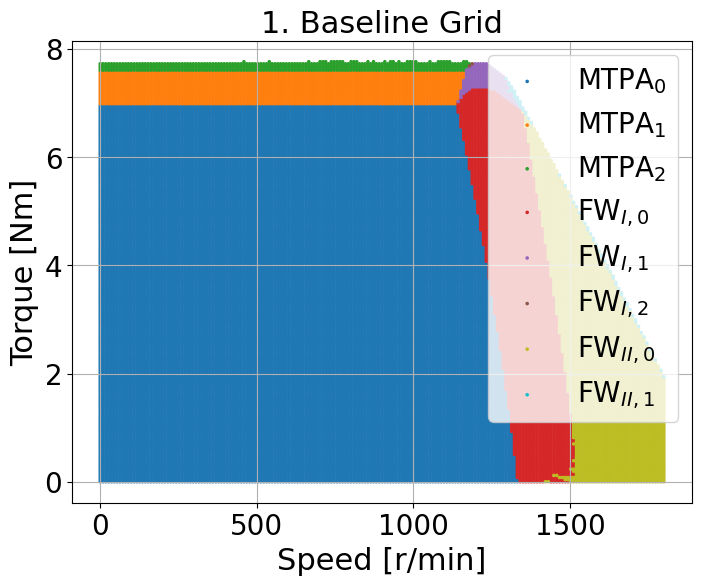

In [8]:
machine_data = grid_to_data(grid_result, k_skip=1)
plot_grid_segments(machine_data, title="1. Baseline Grid")

## Next steps

- **Notebook 2 — Neural Optimization.** Same workflow, but with a
  trained neural torque model (`ModelNeural`) in place of the
  analytical one. Demonstrates that the library's model is pluggable.
- **Notebook 3 — Comparison.** Side-by-side analysis of the two grids:
  per-cell torque residual, Joule-loss reduction, current-trajectory
  differences, and validation of both models against measured data.